Predictions:
2022 : 1316.4438706515793
2023 : 1328.171808499661
2024 : 1339.899746347739


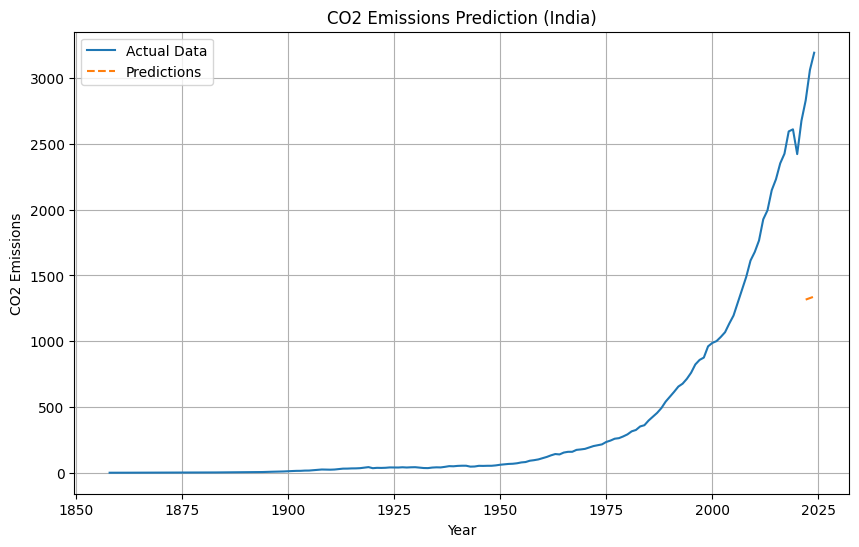

In [4]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load working dataset (NEW LINK)
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

# Filter India data
df_india = df[df['country'] == 'India']

# Take only needed columns
df_india = df_india[['year', 'co2']].dropna()

# Prepare data
X = df_india['year'].values.reshape(-1, 1)
y = df_india['co2'].values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict future values
future_years = [[2022], [2023], [2024]]
predictions = model.predict(future_years)

print("Predictions:")
for year, pred in zip([2022, 2023, 2024], predictions):
    print(year, ":", pred)

# Plot graph
plt.figure(figsize=(10,6))
plt.plot(df_india['year'], df_india['co2'], label='Actual Data')
plt.plot([2022, 2023, 2024], predictions, linestyle='--', label='Predictions')
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.title("CO2 Emissions Prediction (India)")
plt.legend()
plt.grid()
plt.show()

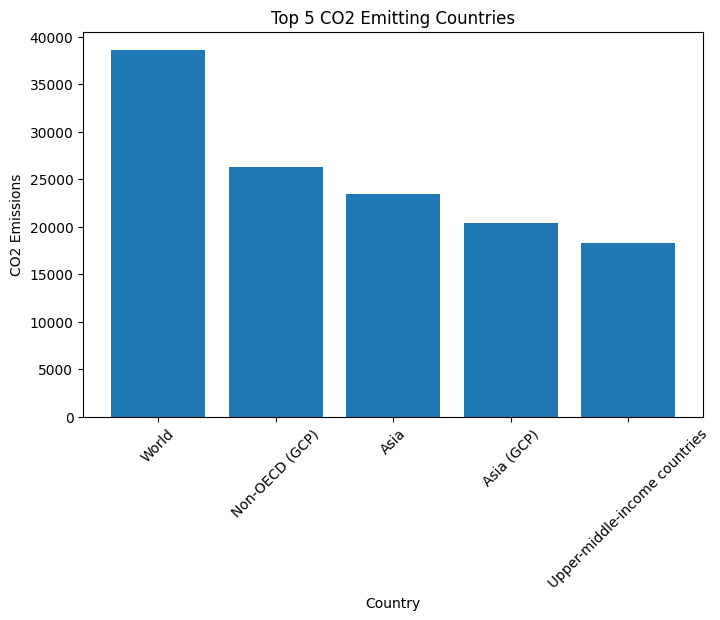

In [5]:
# Top 5 countries with highest emissions (latest year)
latest_year = df[df['year'] == df['year'].max()]
top_countries = latest_year.sort_values(by='co2', ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.bar(top_countries['country'], top_countries['co2'])
plt.title("Top 5 CO2 Emitting Countries")
plt.xlabel("Country")
plt.ylabel("CO2 Emissions")
plt.xticks(rotation=45)
plt.show()

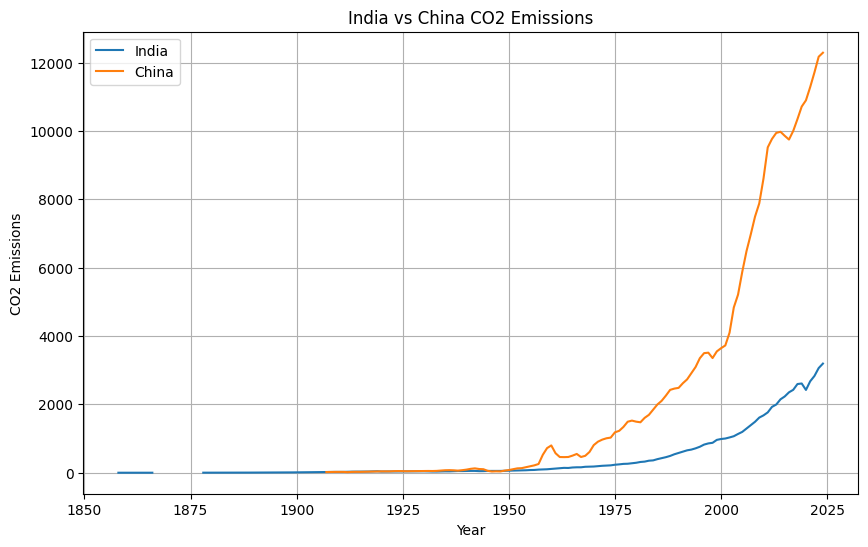

In [6]:
# India vs China comparison
countries = ['India', 'China']
df_compare = df[df['country'].isin(countries)]

plt.figure(figsize=(10,6))
for country in countries:
    data = df_compare[df_compare['country'] == country]
    plt.plot(data['year'], data['co2'], label=country)

plt.title("India vs China CO2 Emissions")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.legend()
plt.grid()
plt.show()